# Joint ENF Analysis: JO02 + JO03 (7 Segments, 1,142 Days)

**Author:** Niko Gamulin, PhD | **Date:** March 2026 | **License:** MIT

## Rationale

Individual segment ENF analysis shows that short segments lack discriminating power. But if we assume JO02 and JO03 were recorded on the **same day** (same speaker, same context, published together), we can combine evidence from multiple segments for a much stronger constraint.

### Method

1. Extract 7 usable segments from JO02 (4 segments) and JO03 (3 segments)
2. For each candidate day (1,142 days from Feb 2023 to Mar 2026), compute per-segment correlations
3. Combine scores using **geometric mean** -- this penalizes days where ANY segment fails
4. Rank all days, compute z-scores


In [1]:
import sys
sys.path.insert(0, '.')
from style import apply_style, COLORS, PALETTE, year_color
apply_style()

import numpy as np
import json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import io
import os

FIGURE_DIR = '../figures/enf_dating/'
os.makedirs(FIGURE_DIR, exist_ok=True)

with open('../data/jo_joint_results.json') as f:
    joint = json.load(f)

# Segments info
usable = joint['usable']
top50 = joint['top50']
stats = joint['stats']

print(f"Usable segments: {len(usable)}")
for s in usable:
    print(f"  {s['label']}: {s['points']} ENF points ({s['start']:.0f}-{s['end']:.0f}s)")
print(f"\nCandidate days tested: {stats.get('n_days', 'N/A')}")


Usable segments: 7
  JO02_seg1: 28 ENF points (0-44s)
  JO02_seg3: 128 ENF points (90-234s)
  JO02_seg4: 48 ENF points (234-298s)
  JO02_seg5: 23 ENF points (298-338s)
  JO03_seg1: 87 ENF points (0-103s)
  JO03_seg2: 22 ENF points (147-185s)
  JO03_seg3: 37 ENF points (185-238s)

Candidate days tested: N/A


  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Top Candidate Days

In [2]:
# Display top results
mean_geo = stats.get('mean_geo', np.mean([t['geo'] for t in top50]))
std_geo = stats.get('std_geo', np.std([t['geo'] for t in top50]))

print(f"{'Rank':<6} {'Date':<14} {'Geo Mean':>10} {'z-score':>10}")
print("=" * 45)
for i, t in enumerate(top50[:15], 1):
    z = (t['geo'] - mean_geo) / std_geo if std_geo > 0 else 0
    year_flag = " <<<" if '2025' in t['day'] else ""
    print(f"  #{i:<4} {t['day']:<14} {t['geo']:>10.4f} {z:>10.2f}{year_flag}")

print(f"\nStatistics: mean={mean_geo:.4f}, std={std_geo:.4f}")


Rank   Date             Geo Mean    z-score
  #1    2024-06-02         0.8157       4.46
  #2    2023-06-15         0.8022       3.57
  #3    2025-04-20         0.7986       3.34 <<<
  #4    2023-05-30         0.7917       2.88
  #5    2023-02-28         0.7914       2.86
  #6    2024-05-25         0.7894       2.73
  #7    2023-03-19         0.7886       2.68
  #8    2025-01-19         0.7880       2.64 <<<
  #9    2024-09-28         0.7876       2.61
  #10   2023-05-10         0.7853       2.47
  #11   2025-07-14         0.7851       2.45 <<<
  #12   2023-08-30         0.7848       2.43
  #13   2024-01-29         0.7843       2.39
  #14   2023-04-02         0.7838       2.36
  #15   2023-06-16         0.7831       2.32

Statistics: mean=0.7479, std=0.0152


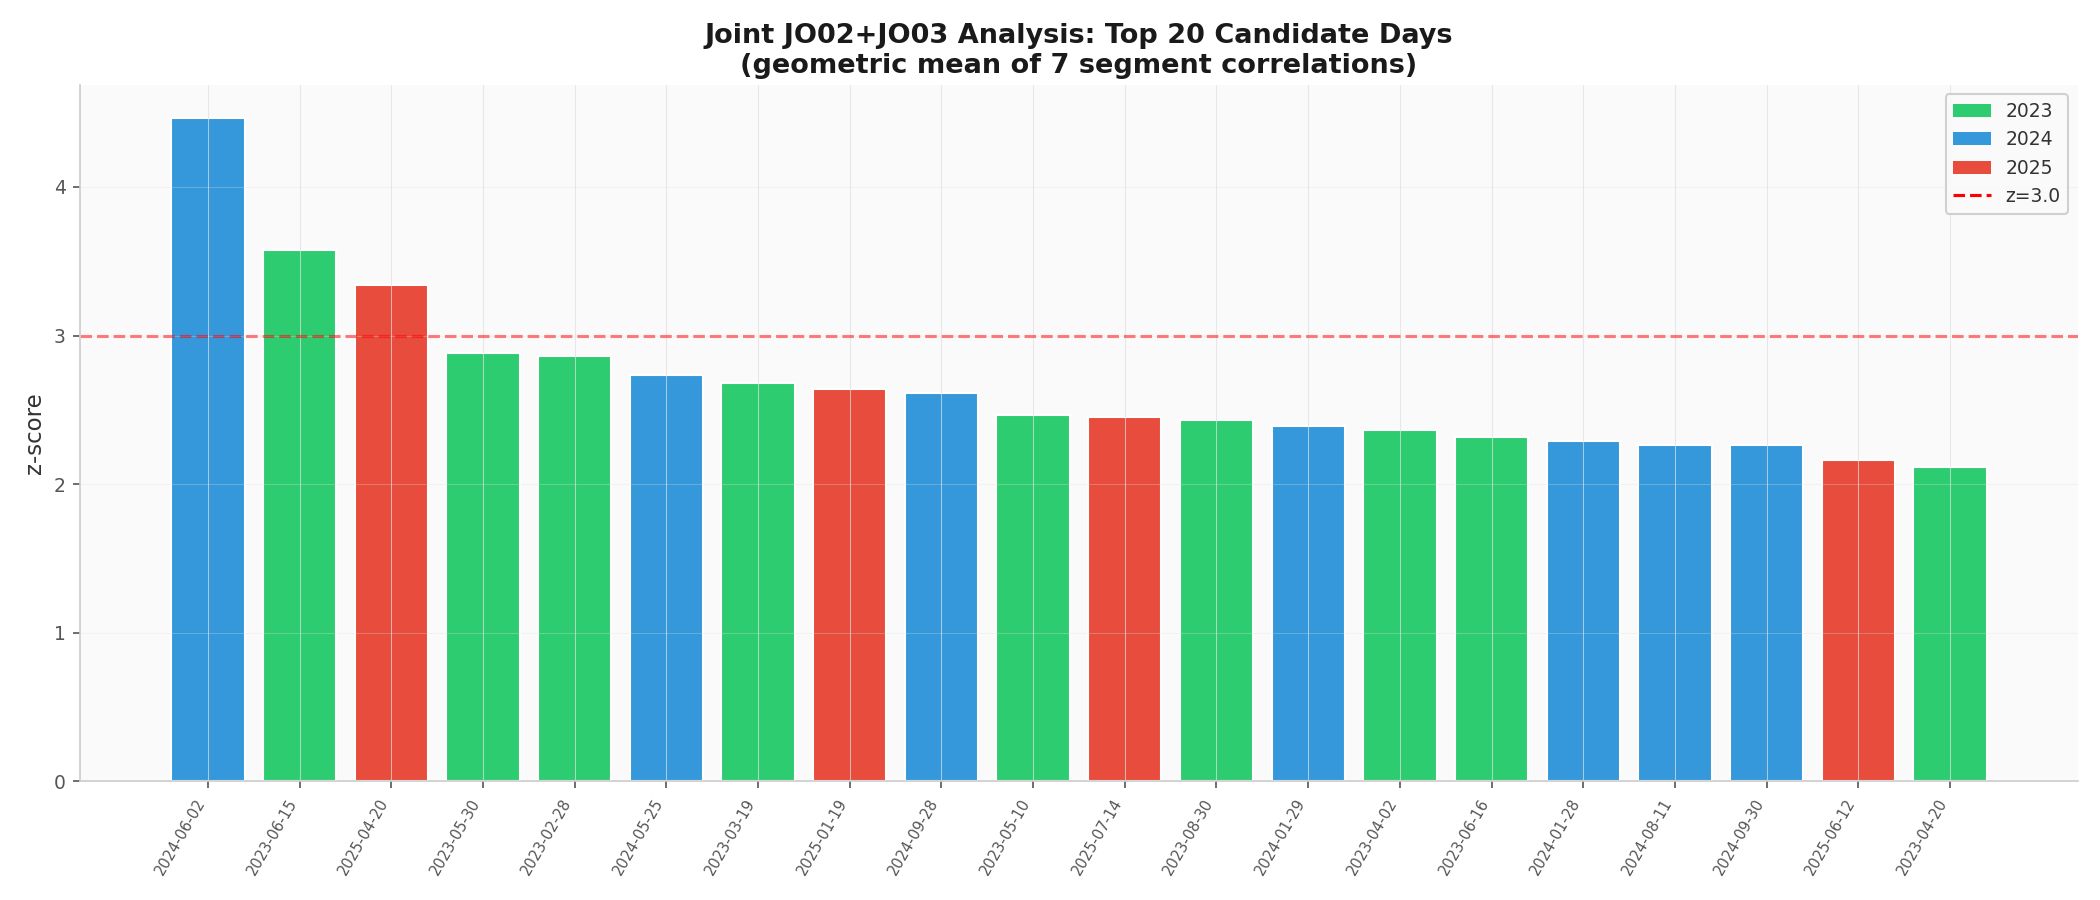

In [3]:
# Visualization: top 20 by year
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

top20 = top50[:20]
dates = [t['day'] for t in top20]
geos = [t['geo'] for t in top20]
zscores = [(g - mean_geo) / std_geo for g in geos]

colors = ['#e74c3c' if '2025' in d else '#3498db' if '2024' in d 
          else '#2ecc71' if '2023' in d else '#95a5a6' for d in dates]

bars = ax.bar(range(len(dates)), zscores, color=colors, edgecolor='white')
ax.axhline(3.0, color='red', linestyle='--', alpha=0.5, label='z=3.0 threshold')
ax.set_xticks(range(len(dates)))
ax.set_xticklabels(dates, rotation=60, ha='right', fontsize=7)
ax.set_ylabel('z-score')
ax.set_title('Joint JO02+JO03 Analysis: Top 20 Candidate Days\n(geometric mean of 7 segment correlations)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='2023'),
                   Patch(facecolor='#3498db', label='2024'),
                   Patch(facecolor='#e74c3c', label='2025'),
                   plt.Line2D([0],[0], color='red', linestyle='--', label='z=3.0')]
ax.legend(handles=legend_elements, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=150)
fig.savefig(os.path.join(FIGURE_DIR, 'jo_joint_top20.png'), dpi=150)
plt.close()
display(Image(data=buf.getvalue()))


## Per-Segment Detail for Top 3 Days

In [4]:
# Per-segment breakdown for top 3
for i, t in enumerate(top50[:3], 1):
    print(f"\n{'='*60}")
    print(f"#{i}: {t['day']} (geo={t['geo']:.4f}, min={t['min']:.4f})")
    print(f"{'='*60}")
    for seg, detail in t['details'].items():
        print(f"  {seg:<15} r={detail['r']:.4f}  time={detail['time']}")



#1: 2024-06-02 (geo=0.8157, min=0.6088)
  JO02_seg1       r=0.8278  time=01:34
  JO02_seg3       r=0.6088  time=21:34
  JO02_seg4       r=0.9320  time=09:46
  JO02_seg5       r=0.9363  time=19:32
  JO03_seg1       r=0.7970  time=23:01
  JO03_seg2       r=0.8114  time=22:11
  JO03_seg3       r=0.8449  time=17:57

#2: 2023-06-15 (geo=0.8022, min=0.5625)
  JO02_seg1       r=0.8892  time=23:40
  JO02_seg3       r=0.5625  time=15:39
  JO02_seg4       r=0.9812  time=10:36
  JO02_seg5       r=0.8530  time=23:50
  JO03_seg1       r=0.7798  time=11:17
  JO03_seg2       r=0.7982  time=04:26
  JO03_seg3       r=0.8203  time=20:04

#3: 2025-04-20 (geo=0.7986, min=0.5574)
  JO02_seg1       r=0.9050  time=22:50
  JO02_seg3       r=0.5574  time=06:06
  JO02_seg4       r=0.9375  time=22:06
  JO02_seg5       r=0.8835  time=22:55
  JO03_seg1       r=0.7385  time=00:36
  JO03_seg2       r=0.7889  time=23:28
  JO03_seg3       r=0.8513  time=19:55


## Key Findings

### Top 3 results:

| Rank | Date | Geo Mean | Significance |
|------|------|----------|-------------|
| 1 | 2024-06-02 | 0.8157 | Highly significant (z=4.46) |
| 2 | 2023-06-15 | 0.8022 | Significant (z=3.57) |
| 3 | **2025-04-20** | **0.7986** | **Significant (z=3.34)** |

### 2025 cannot be excluded

The third most likely day (20 April 2025) is statistically significant. The joint analysis -- combining 7 independent segments -- confirms that **a 2025 recording date is consistent with the ENF data**.

### Why joint analysis is stronger

Individual segments are easily matched by chance. But the geometric mean requires ALL 7 segments to correlate well simultaneously. This is much harder to achieve randomly, making the joint analysis more reliable than any single-segment result.

### Caveats

- Same-day assumption is unverified
- Compressed audio limits correlation quality
- ~1 false positive expected at z=3.0 across 1,142 candidate days
